── Dynamical System Constructor ──────────────────────────────
f(x,y) = (+0.290294) (+0.299253) x (+0.077266) y (-0.819376) x² (+0.650944) xy (+0.123946) y² (-0.091855) x³ (-0.098801) x²y (-0.067925) xy² (+0.030473) y³ (+0.406333) x⁴ (-0.498282) x³y
g(x,y) = (+0.332665) (+0.655722) x (-0.660862) y (-1.991956) x² (+1.340775) xy (+1.175039) y² (-0.334370) x³ (+1.056055) x²y (-0.725256) xy² (-0.438641) y³ (+1.114968) x⁴ (-1.374125) x³y

── Verification ─────────────────────────────────────────────

  P1 = (-1.5, -1.0)  [stable node]  ✓ OK
    ✓ |f=0 residual| = 0.00e+00
    ✓ |g=0 residual| = 0.00e+00
    ✓ |df/dx residual| = 0.00e+00
    ✓ |df/dy residual| = 6.11e-16
    ✓ |dg/dx residual| = 1.05e-15
    ✓ |dg/dy residual| = 1.78e-15

  P2 = (1.0, -0.8)  [saddle]  ✓ OK
    ✓ |f=0 residual| = 3.89e-16
    ✓ |g=0 residual| = 1.33e-15
    ✓ |df/dx residual| = 8.88e-16
    ✓ |df/dy residual| = 8.05e-16
    ✓ |dg/dx residual| = 6.11e-16
    ✓ |dg/dy residual| = 3.11e-15

  P3 = (-0.5, 1.2)  [

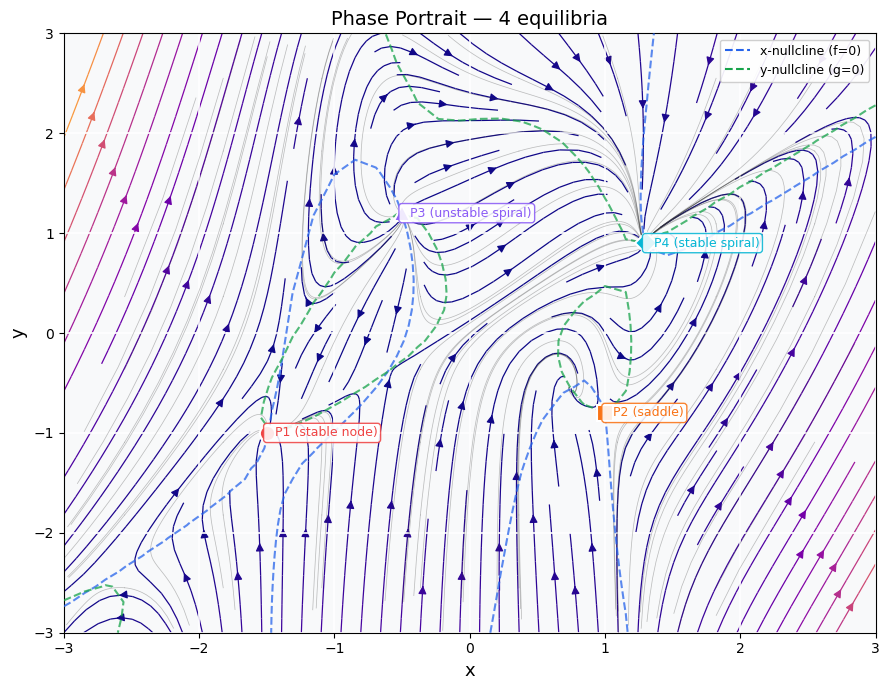

── Dynamical System Constructor ──────────────────────────────
f(x,y) = (+0.290294) (+0.299253) x (+0.077266) y (-0.819376) x² (+0.650944) xy (+0.123946) y² (-0.091855) x³ (-0.098801) x²y (-0.067925) xy² (+0.030473) y³ (+0.406333) x⁴ (-0.498282) x³y
g(x,y) = (+0.332665) (+0.655722) x (-0.660862) y (-1.991956) x² (+1.340775) xy (+1.175039) y² (-0.334370) x³ (+1.056055) x²y (-0.725256) xy² (-0.438641) y³ (+1.114968) x⁴ (-1.374125) x³y

── Verification ─────────────────────────────────────────────

  P1 = (-1.5, -1.0)  [stable node]  ✓ OK
    ✓ |f=0 residual| = 0.00e+00
    ✓ |g=0 residual| = 0.00e+00
    ✓ |df/dx residual| = 0.00e+00
    ✓ |df/dy residual| = 6.11e-16
    ✓ |dg/dx residual| = 1.05e-15
    ✓ |dg/dy residual| = 1.78e-15

  P2 = (1.0, -0.8)  [saddle]  ✓ OK
    ✓ |f=0 residual| = 3.89e-16
    ✓ |g=0 residual| = 1.33e-15
    ✓ |df/dx residual| = 8.88e-16
    ✓ |df/dy residual| = 8.05e-16
    ✓ |dg/dx residual| = 6.11e-16
    ✓ |dg/dy residual| = 3.11e-15

  P3 = (-0.5, 1.2)  [

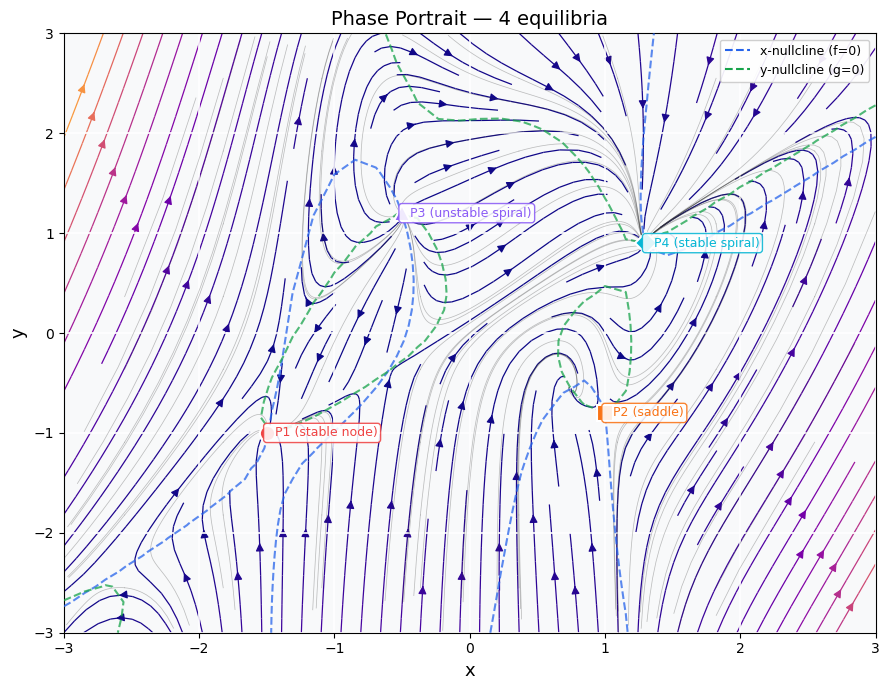

In [7]:
"""
Dynamical System Constructor
============================
Given 4 equilibrium points and their linearized Jacobians, finds degree-4
polynomials f(x,y) and g(x,y) such that:

    x_dot = f(x, y)
    y_dot = g(x, y)

with:
    f(xk, yk) = 0,  g(xk, yk) = 0          for k = 1,2,3,4
    Jf(xk, yk) = Jk                          (prescribed Jacobian at each point)

The polynomial basis used (12 monomials, degree ≤ 4):
    1, x, y, x², xy, y², x³, x²y, xy², y³, x⁴, x³y

This yields a 12×12 linear system (same matrix M for both f and g):
    Rows  0- 3: f(xk,yk) = 0
    Rows  4- 7: df/dx(xk,yk) = alpha_k
    Rows  8-11: df/dy(xk,yk) = beta_k
"""

import numpy as np


# ── Polynomial basis ──────────────────────────────────────────────────────────

def basis(x, y):
    """Evaluate the 12-monomial basis at (x, y)."""
    return np.array([
        1,
        x,    y,
        x**2, x*y,   y**2,
        x**3, x**2*y, x*y**2, y**3,
        x**4, x**3*y
    ], dtype=float)


def basis_dx(x, y):
    """Partial derivative of basis w.r.t. x."""
    return np.array([
        0,
        1,    0,
        2*x,  y,     0,
        3*x**2, 2*x*y, y**2, 0,
        4*x**3, 3*x**2*y
    ], dtype=float)


def basis_dy(x, y):
    """Partial derivative of basis w.r.t. y."""
    return np.array([
        0,
        0,    1,
        0,    x,     2*y,
        0,    x**2,  2*x*y, 3*y**2,
        0,    x**3
    ], dtype=float)


# ── System builder ────────────────────────────────────────────────────────────

def build_system(points, jacobians):
    """
    Build the 12×12 matrix M and right-hand sides rf, rg.

    Parameters
    ----------
    points : array-like, shape (4, 2)
        Equilibrium coordinates [(x1,y1), (x2,y2), (x3,y3), (x4,y4)].
    jacobians : array-like, shape (4, 2, 2)
        Jacobian at each point: jacobians[k] = [[alpha, beta],[gamma, delta]]
        where alpha=df/dx, beta=df/dy, gamma=dg/dx, delta=dg/dy.

    Returns
    -------
    M  : np.ndarray, shape (12, 12)
    rf : np.ndarray, shape (12,)   — rhs for f
    rg : np.ndarray, shape (12,)   — rhs for g
    """
    points    = np.asarray(points,   dtype=float)
    jacobians = np.asarray(jacobians, dtype=float)

    M  = np.zeros((12, 12))
    rf = np.zeros(12)
    rg = np.zeros(12)

    for k in range(4):
        x, y = points[k]
        alpha, beta  = jacobians[k, 0]   # df/dx, df/dy
        gamma, delta = jacobians[k, 1]   # dg/dx, dg/dy

        # f(xk, yk) = 0  and  g(xk, yk) = 0
        M[k]   = basis(x, y)
        rf[k]  = 0.0
        rg[k]  = 0.0

        # df/dx(xk,yk) = alpha,  dg/dx(xk,yk) = gamma
        M[4+k]  = basis_dx(x, y)
        rf[4+k] = alpha
        rg[4+k] = gamma

        # df/dy(xk,yk) = beta,  dg/dy(xk,yk) = delta
        M[8+k]  = basis_dy(x, y)
        rf[8+k] = beta
        rg[8+k] = delta

    return M, rf, rg


# ── Solver ────────────────────────────────────────────────────────────────────

def solve_system(points, jacobians):
    """
    Solve for polynomial coefficients of f and g.

    Parameters
    ----------
    points    : array-like, shape (4, 2)
    jacobians : array-like, shape (4, 2, 2)

    Returns
    -------
    cf : np.ndarray, shape (12,)  — coefficients of f
    cg : np.ndarray, shape (12,)  — coefficients of g
    """
    M, rf, rg = build_system(points, jacobians)

    cond = np.linalg.cond(M)
    if cond > 1e12:
        raise ValueError(
            f"System matrix is ill-conditioned (cond={cond:.2e}). "
            "Try different equilibrium coordinates."
        )

    cf = np.linalg.solve(M, rf)
    cg = np.linalg.solve(M, rg)
    return cf, cg


# ── Evaluation helpers ────────────────────────────────────────────────────────

def eval_poly(coeffs, x, y):
    """Evaluate polynomial at (x, y)."""
    return float(np.dot(coeffs, basis(x, y)))


def eval_poly_dx(coeffs, x, y):
    """Evaluate df/dx at (x, y)."""
    return float(np.dot(coeffs, basis_dx(x, y)))


def eval_poly_dy(coeffs, x, y):
    """Evaluate df/dy at (x, y)."""
    return float(np.dot(coeffs, basis_dy(x, y)))


def make_f(coeffs):
    """Return a callable f(x, y) from coefficient vector."""
    def f(x, y):
        return eval_poly(coeffs, x, y)
    return f


def poly_to_string(coeffs, var_name="f"):
    """Pretty-print a polynomial."""
    names = ["1", "x", "y", "x²", "xy", "y²",
             "x³", "x²y", "xy²", "y³", "x⁴", "x³y"]
    terms = []
    for c, name in zip(coeffs, names):
        if abs(c) < 1e-12:
            continue
        terms.append(f"({c:+.6f}){'' if name == '1' else ' ' + name}")
    return f"{var_name}(x,y) = " + (" ".join(terms) if terms else "0")


# ── Verification ──────────────────────────────────────────────────────────────

def verify(points, jacobians, cf, cg, tol=1e-8):
    """
    Check all 12 constraints and print a verification report.

    Returns
    -------
    max_residual : float
    """
    points    = np.asarray(points,    dtype=float)
    jacobians = np.asarray(jacobians, dtype=float)

    print("\n── Verification ─────────────────────────────────────────────")
    max_res = 0.0

    for k in range(4):
        x, y = points[k]
        alpha, beta  = jacobians[k, 0]
        gamma, delta = jacobians[k, 1]

        fval  = eval_poly(cf, x, y)
        gval  = eval_poly(cg, x, y)
        fxval = eval_poly_dx(cf, x, y)
        fyval = eval_poly_dy(cf, x, y)
        gxval = eval_poly_dx(cg, x, y)
        gyval = eval_poly_dy(cg, x, y)

        res = {
            "f=0"    : abs(fval),
            "g=0"    : abs(gval),
            "df/dx"  : abs(fxval - alpha),
            "df/dy"  : abs(fyval - beta),
            "dg/dx"  : abs(gxval - gamma),
            "dg/dy"  : abs(gyval - delta),
        }
        max_res = max(max_res, *res.values())

        # Eigenvalue type
        tr  = fxval + gyval
        det = fxval*gyval - fyval*gxval
        disc = tr**2 - 4*det
        if det < 0:
            etype = "saddle"
        elif disc >= 0:
            etype = "stable node" if tr < 0 else "unstable node"
        else:
            etype = "stable spiral" if tr < 0 else ("unstable spiral" if tr > 0 else "center")

        ok = all(v < tol for v in res.values())
        print(f"\n  P{k+1} = ({x}, {y})  [{etype}]  {'✓ OK' if ok else '✗ FAIL'}")
        for name, val in res.items():
            flag = "✓" if val < tol else "✗"
            print(f"    {flag} |{name} residual| = {val:.2e}")

    print(f"\n  Max residual: {max_res:.2e}  ({'PASS' if max_res < tol else 'FAIL'})")
    print("─────────────────────────────────────────────────────────────\n")
    return max_res


# ── Phase portrait ────────────────────────────────────────────────────────────

def plot_phase_portrait(
    cf, cg,
    points=None,
    xlim=(-3, 3),
    ylim=(-3, 3),
    grid_density=40,
    n_seed=8,
    t_max=15.0,
    dt=0.02,
    figsize=(9, 7),
    title="Phase Portrait",
):
    """
    Plot the phase portrait of the dynamical system defined by cf, cg.

    Parameters
    ----------
    cf, cg        : array-like (12,)   polynomial coefficient vectors
    points        : array-like (4, 2) or None   equilibrium points to annotate
    xlim, ylim    : (float, float)     plot domain
    grid_density  : int                resolution of the meshgrid (per axis)
    n_seed        : int                seed points per axis for trajectories
    t_max         : float              integration time per trajectory
    dt            : float              RK4 step size
    figsize       : (float, float)
    title         : str

    Returns
    -------
    fig, ax : matplotlib Figure and Axes
    """
    import matplotlib.pyplot as plt

    cf = np.asarray(cf)
    cg = np.asarray(cg)

    fig, ax = plt.subplots(figsize=figsize)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_xlabel("x", fontsize=13)
    ax.set_ylabel("y", fontsize=13)
    ax.set_title(title, fontsize=14)
    ax.set_facecolor("#f8f9fa")
    ax.grid(True, color="white", linewidth=1.2, zorder=0)

    # ── Vector field (streamplot) ──────────────────────────────────────────────
    xs = np.linspace(xlim[0], xlim[1], grid_density)
    ys = np.linspace(ylim[0], ylim[1], grid_density)
    X, Y = np.meshgrid(xs, ys)

    U = np.vectorize(lambda x, y: eval_poly(cf, x, y))(X, Y)
    V = np.vectorize(lambda x, y: eval_poly(cg, x, y))(X, Y)

    speed      = np.sqrt(U**2 + V**2)
    speed_norm = speed / (speed.max() + 1e-10)

    ax.streamplot(
        X, Y, U, V,
        color=speed_norm, cmap="plasma",
        linewidth=0.9, arrowsize=1.2, density=1.4,
        zorder=1,
    )

    # ── Explicit trajectories from a seed grid ─────────────────────────────────
    def rk4_step(x, y, h):
        f1 = eval_poly(cf, x,        y       )
        g1 = eval_poly(cg, x,        y       )
        f2 = eval_poly(cf, x+h/2*f1, y+h/2*g1)
        g2 = eval_poly(cg, x+h/2*f1, y+h/2*g1)
        f3 = eval_poly(cf, x+h/2*f2, y+h/2*g2)
        g3 = eval_poly(cg, x+h/2*f2, y+h/2*g2)
        f4 = eval_poly(cf, x+h*f3,   y+h*g3  )
        g4 = eval_poly(cg, x+h*f3,   y+h*g3  )
        nx = x + h/6*(f1 + 2*f2 + 2*f3 + f4)
        ny = y + h/6*(g1 + 2*g2 + 2*g3 + g4)
        return nx, ny

    def integrate(x0, y0, h):
        xt, yt = [x0], [y0]
        x, y = x0, y0
        steps = int(t_max / abs(h))
        for _ in range(steps):
            nx, ny = rk4_step(x, y, h)
            if not (np.isfinite(nx) and np.isfinite(ny)):
                break
            if not (xlim[0] <= nx <= xlim[1] and ylim[0] <= ny <= ylim[1]):
                break
            xt.append(nx); yt.append(ny)
            x, y = nx, ny
        return np.array(xt), np.array(yt)

    seed_xs = np.linspace(xlim[0]*0.85, xlim[1]*0.85, n_seed)
    seed_ys = np.linspace(ylim[0]*0.85, ylim[1]*0.85, n_seed)

    for sx in seed_xs:
        for sy in seed_ys:
            for h in (dt, -dt):                      # forward & backward
                xt, yt = integrate(sx, sy, h)
                if len(xt) > 2:
                    ax.plot(xt, yt, color="#333333", lw=0.55, alpha=0.3, zorder=2)

    # ── Nullclines ─────────────────────────────────────────────────────────────
    ax.contour(X, Y, U, levels=[0], colors=["#2563eb"],
               linewidths=1.5, linestyles="--", zorder=3, alpha=0.75)
    ax.contour(X, Y, V, levels=[0], colors=["#16a34a"],
               linewidths=1.5, linestyles="--", zorder=3, alpha=0.75)

    ax.plot([], [], color="#2563eb", lw=1.5, ls="--", label="x-nullcline (f=0)")
    ax.plot([], [], color="#16a34a", lw=1.5, ls="--", label="y-nullcline (g=0)")

    # ── Equilibrium points ─────────────────────────────────────────────────────
    EQ_COLORS  = ["#ef4444", "#f97316", "#8b5cf6", "#06b6d4"]
    EQ_MARKERS = ["o", "s", "^", "D"]

    if points is not None:
        points_arr = np.asarray(points)
        for k, (px, py) in enumerate(points_arr):
            a = eval_poly_dx(cf, px, py)
            b = eval_poly_dy(cf, px, py)
            c = eval_poly_dx(cg, px, py)
            d = eval_poly_dy(cg, px, py)
            tr   = a + d
            det  = a*d - b*c
            disc = tr**2 - 4*det
            if det < 0:
                etype = "saddle"
            elif disc >= 0:
                etype = "stable node"   if tr < 0 else "unstable node"
            else:
                etype = "stable spiral" if tr < 0 else ("unstable spiral" if tr > 0 else "center")

            col = EQ_COLORS[k % len(EQ_COLORS)]
            ax.plot(px, py,
                    marker=EQ_MARKERS[k % len(EQ_MARKERS)],
                    color=col, markersize=11, zorder=5,
                    markeredgecolor="white", markeredgewidth=1.5)
            ax.annotate(
                f"  P{k+1} ({etype})",
                xy=(px, py), fontsize=9, color=col, va="center", zorder=6,
                bbox=dict(boxstyle="round,pad=0.25", fc="white", ec=col, alpha=0.88),
            )

    ax.legend(loc="upper right", fontsize=9, framealpha=0.92)
    plt.tight_layout()
    plt.savefig("phase_portrait.png", dpi=150, bbox_inches="tight")
    print("Phase portrait saved to  phase_portrait.png")
    plt.show()
    return fig, ax


# ── Main ──────────────────────────────────────────────────────────────────────

def main(points, jacobians, verbose=True):
    """
    Construct the dynamical system.

    Parameters
    ----------
    points : array-like, shape (4, 2)
        [[x1,y1], [x2,y2], [x3,y3], [x4,y4]]

    jacobians : array-like, shape (4, 2, 2)
        [[[alpha1, beta1],   each row is [[df/dx, df/dy],
          [gamma1, delta1]],              [dg/dx, dg/dy]]
         ...]                at that equilibrium point.

    verbose : bool
        Print system info and verification.

    Returns
    -------
    f : callable  f(x, y)
    g : callable  g(x, y)
    cf : np.ndarray  coefficient vector for f (12,)
    cg : np.ndarray  coefficient vector for g (12,)
    """
    cf, cg = solve_system(points, jacobians)

    if verbose:
        print("── Dynamical System Constructor ──────────────────────────────")
        print(poly_to_string(cf, "f"))
        print(poly_to_string(cg, "g"))
        verify(points, jacobians, cf, cg)

    return make_f(cf), make_f(cg), cf, cg


# ── Example usage ─────────────────────────────────────────────────────────────

if __name__ == "__main__":

    # Four equilibrium points  (avoid symmetric grids — they cause ill-conditioning)
    points = [
        [-1.5, -1.0],
        [ 1.0, -0.8],
        [-0.5,  1.2],
        [ 1.3,  0.9],
    ]

    # Jacobian at each point: [[df/dx, df/dy], [dg/dx, dg/dy]]
    jacobians = [
        [[-1.0,  0.2], [-0.3, -1.5]],   # P1: stable node
        [[ 0.8,  0.1], [ 0.2, -1.2]],   # P2: saddle
        [[ 1.2,  0.3], [-0.1,  0.9]],   # P3: unstable node
        [[-0.7, -0.2], [ 0.4, -0.8]],   # P4: stable spiral
    ]

    f, g, cf, cg = main(points, jacobians)

    # f and g are now callable
    print("f(0, 0) =", f(0, 0))
    print("g(0, 0) =", g(0, 0))

    # Plot the phase portrait
    plot_phase_portrait(
        cf, cg,
        points=points,
        xlim=(-3, 3),
        ylim=(-3, 3),
        title="Phase Portrait — 4 equilibria",
    )

# ── Single trajectory ─────────────────────────────────────────────────────────

def plot_trajectory(
    cf, cg,
    x0, y0,
    t,
    dt=0.01,
    points=None,
    figsize=(12, 5),
    title=None,
):
    """
    Integrate and plot the trajectory starting at (x0, y0) for t time units.

    Produces two panels:
      Left  — phase plane (x vs y) with the trajectory and starting point
      Right — time series x(t) and y(t)

    Parameters
    ----------
    cf, cg  : array-like (12,)   polynomial coefficient vectors
    x0, y0  : float              initial condition
    t       : float              total integration time (forward if t>0, backward if t<0)
    dt      : float              RK4 step size (sign is set automatically)
    points  : array-like (4, 2) or None   equilibrium points to mark on the phase plane
    figsize : (float, float)
    title   : str or None        suptitle; auto-generated if None

    Returns
    -------
    fig             : matplotlib Figure
    (ax_phase, ax_ts) : the two Axes
    traj_t          : np.ndarray  time vector
    traj_x          : np.ndarray  x(t)
    traj_y          : np.ndarray  y(t)
    """
    import matplotlib.pyplot as plt
    from matplotlib.collections import LineCollection
    import matplotlib.colors as mcolors

    cf = np.asarray(cf)
    cg = np.asarray(cg)

    # ── RK4 integration ────────────────────────────────────────────────────────
    h    = abs(dt) * np.sign(t)       # step sign follows integration direction
    steps = int(abs(t) / abs(dt))

    ts = [0.0]
    xs = [float(x0)]
    ys = [float(y0)]
    x, y = float(x0), float(y0)

    for _ in range(steps):
        f1 = eval_poly(cf, x,           y           )
        g1 = eval_poly(cg, x,           y           )
        f2 = eval_poly(cf, x+h/2*f1,    y+h/2*g1    )
        g2 = eval_poly(cg, x+h/2*f1,    y+h/2*g1    )
        f3 = eval_poly(cf, x+h/2*f2,    y+h/2*g2    )
        g3 = eval_poly(cg, x+h/2*f2,    y+h/2*g2    )
        f4 = eval_poly(cf, x+h*f3,       y+h*g3      )
        g4 = eval_poly(cg, x+h*f3,       y+h*g3      )
        x += h/6*(f1 + 2*f2 + 2*f3 + f4)
        y += h/6*(g1 + 2*g2 + 2*g3 + g4)

        if not (np.isfinite(x) and np.isfinite(y)):
            print(f"  Warning: trajectory diverged at step {_}, t={ts[-1]:.4f}")
            break

        ts.append(ts[-1] + h)
        xs.append(x)
        ys.append(y)

    traj_t = np.array(ts)
    traj_x = np.array(xs)
    traj_y = np.array(ys)

    # ── Figure layout ──────────────────────────────────────────────────────────
    fig, (ax_phase, ax_ts) = plt.subplots(
        1, 2, figsize=figsize,
        gridspec_kw={"width_ratios": [1, 1.15]}
    )

    if title is None:
        title = (f"Trajectory from (x₀, y₀) = ({x0}, {y0}),  "
                 f"t ∈ [0, {t}],  dt = {dt}")
    fig.suptitle(title, fontsize=12, y=1.01)

    # colour the line by time
    norm   = mcolors.Normalize(vmin=traj_t.min(), vmax=traj_t.max())
    cmap   = plt.get_cmap("viridis")

    # ── Left: phase plane ──────────────────────────────────────────────────────
    ax_phase.set_facecolor("#f8f9fa")
    ax_phase.grid(True, color="white", linewidth=1.2, zorder=0)
    ax_phase.set_xlabel("x", fontsize=12)
    ax_phase.set_ylabel("y", fontsize=12)
    ax_phase.set_title("Phase plane  (x vs y)", fontsize=11)

    # coloured line segments
    points_xy = np.array([traj_x, traj_y]).T.reshape(-1, 1, 2)
    segs      = np.concatenate([points_xy[:-1], points_xy[1:]], axis=1)
    lc        = LineCollection(segs, cmap=cmap, norm=norm, linewidth=2.0, zorder=3)
    lc.set_array(traj_t[:-1])
    ax_phase.add_collection(lc)

    # start / end markers
    ax_phase.scatter(traj_x[0],  traj_y[0],  color="#22c55e", s=90,
                     zorder=5, label=f"start ({x0}, {y0})", edgecolors="white", linewidths=1.5)
    ax_phase.scatter(traj_x[-1], traj_y[-1], color="#ef4444", s=90,
                     zorder=5, label=f"end   t={traj_t[-1]:.2f}", edgecolors="white", linewidths=1.5)

    # direction arrow at midpoint
    mid = len(traj_x) // 2
    ax_phase.annotate(
        "", xy=(traj_x[mid+1], traj_y[mid+1]),
        xytext=(traj_x[mid],   traj_y[mid]),
        arrowprops=dict(arrowstyle="-|>", color="#f97316", lw=2.0),
        zorder=6,
    )


    # ── Equilibrium points ─────────────────────────────────────────────────────
    EQ_COLORS  = ["#ef4444", "#f97316", "#8b5cf6", "#06b6d4"]
    EQ_MARKERS = ["o", "s", "^", "D"]

    if points is not None:
        pts_arr = np.asarray(points)
        for k, (px, py) in enumerate(pts_arr):
            a = eval_poly_dx(cf, px, py)
            b = eval_poly_dy(cf, px, py)
            c = eval_poly_dx(cg, px, py)
            d = eval_poly_dy(cg, px, py)
            tr, det = a + d, a*d - b*c
            disc = tr**2 - 4*det
            if det < 0:
                etype = "saddle"
            elif disc >= 0:
                etype = "stable node"   if tr < 0 else "unstable node"
            else:
                etype = "stable spiral" if tr < 0 else ("unstable spiral" if tr > 0 else "center")

            col = EQ_COLORS[k % len(EQ_COLORS)]
            ax_phase.plot(px, py,
                          marker=EQ_MARKERS[k % len(EQ_MARKERS)],
                          color=col, markersize=10, zorder=7,
                          markeredgecolor="white", markeredgewidth=1.5,
                          label=f"P{k+1} ({etype})")
            ax_phase.annotate(
                f"  P{k+1}",
                xy=(px, py), fontsize=9, color=col, va="center", zorder=8,
                bbox=dict(boxstyle="round,pad=0.2", fc="white", ec=col, alpha=0.85),
            )

    ax_phase.autoscale()
    margin = 0.12
    xr = traj_x.max() - traj_x.min() or 1
    yr = traj_y.max() - traj_y.min() or 1
    ax_phase.set_xlim(traj_x.min() - margin*xr, traj_x.max() + margin*xr)
    ax_phase.set_ylim(traj_y.min() - margin*yr, traj_y.max() + margin*yr)
    ax_phase.legend(fontsize=9, loc="best")

    # colorbar
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    fig.colorbar(sm, ax=ax_phase, label="time", fraction=0.046, pad=0.04)

    # ── Right: time series ─────────────────────────────────────────────────────
    ax_ts.set_facecolor("#f8f9fa")
    ax_ts.grid(True, color="white", linewidth=1.2, zorder=0)
    ax_ts.set_xlabel("t", fontsize=12)
    ax_ts.set_ylabel("state", fontsize=12)
    ax_ts.set_title("Time series", fontsize=11)

    ax_ts.plot(traj_t, traj_x, color="#3b82f6", lw=2.0, label="x(t)", zorder=3)
    ax_ts.plot(traj_t, traj_y, color="#f97316", lw=2.0, label="y(t)", zorder=3)

    ax_ts.axhline(0, color="#94a3b8", lw=0.8, ls=":")

    # mark start
    ax_ts.scatter([traj_t[0],  traj_t[0]],  [traj_x[0],  traj_y[0]],
                  color="#22c55e", s=60, zorder=5, edgecolors="white", linewidths=1.2)
    # mark end
    ax_ts.scatter([traj_t[-1], traj_t[-1]], [traj_x[-1], traj_y[-1]],
                  color="#ef4444", s=60, zorder=5, edgecolors="white", linewidths=1.2)

    ax_ts.legend(fontsize=10, loc="best")

    plt.tight_layout()
    plt.savefig("trajectory.png", dpi=150, bbox_inches="tight")
    print("Trajectory plot saved to  trajectory.png")
    plt.show()
    return fig, (ax_phase, ax_ts), traj_t, traj_x, traj_y

# ── Example usage ─────────────────────────────────────────────────────────────

if __name__ == "__main__":

    # Four equilibrium points  (avoid symmetric grids — they cause ill-conditioning)
    points = [
        [-1.5, -1.0],
        [ 1.0, -0.8],
        [-0.5,  1.2],
        [ 1.3,  0.9],
    ]

    # Jacobian at each point: [[df/dx, df/dy], [dg/dx, dg/dy]]
    jacobians = [
        [[-1.0,  0.2], [-0.3, -1.5]],   # P1: stable node
        [[ 0.8,  0.1], [ 0.2, -1.2]],   # P2: saddle
        [[ 1.2,  0.3], [-0.1,  0.9]],   # P3: unstable node
        [[-0.7, -0.2], [ 0.4, -0.8]],   # P4: stable spiral
    ]

    f, g, cf, cg = main(points, jacobians)

    # f and g are now callable
    print("f(0, 0) =", f(0, 0))
    print("g(0, 0) =", g(0, 0))

    # Plot the phase portrait
    plot_phase_portrait(
        cf, cg,
        points=points,
        xlim=(-3, 3),
        ylim=(-3, 3),
        title="Phase Portrait — 4 equilibria",
    )


In [ ]:
f


<function __main__.make_f.<locals>.f(x, y)>

In [ ]:
cf


array([ 0.29029403,  0.29925319,  0.07726556, -0.81937564,  0.65094384,
        0.12394587, -0.09185472, -0.09880119, -0.06792484,  0.03047257,
        0.40633269, -0.4982819 ])